In [1]:
from pathlib import Path
import os
import sys

# Make repo imports work even when the kernel starts inside a notebook subdirectory.
_repo_root = Path.cwd().resolve()
while _repo_root != _repo_root.parent and not (_repo_root / 'configs' / 'profiles.py').exists():
    _repo_root = _repo_root.parent
if not (_repo_root / 'configs' / 'profiles.py').exists():
    raise RuntimeError("Failed to locate MADRL_ESS repo root containing configs/profiles.py.")
_repo_root_str = str(_repo_root)
if _repo_root_str not in sys.path:
    sys.path.insert(0, _repo_root_str)
os.chdir(_repo_root)


# train_base_fasttest

Fast test copy of `train_base.ipynb`. It keeps the normal LSTM forecast path, trains an independent MADRL run for 500 episodes, and uses a 2-day training window so the result can be inspected quickly without overwriting the canonical `madrl_base` record.


In [2]:

import json
from copy import deepcopy
import matplotlib.pyplot as plt

from pprint import pprint

import pandas as pd
from IPython.display import display

from configs.experiment_config import MADRL_NOTEBOOK_SPECS
from configs.profiles import compose_experiment_config, project_root, summarize_experiment
from predictors.mainline_forecast import get_mainline_forecast_controls
from predictors.shared_data import ensure_madrl_shared_data
from scripts.mainline_compare import collect_madrl_rollout, compare_rollout_metrics
from scripts.utils.grid_notebook_workflow import apply_notebook_experiment_settings, plot_battery_power_and_soc_comparison, plot_net_load_comparison, plot_power_balance_comparison, plot_price_prediction_comparison, plot_voltage_profile_comparison, resolve_madrl_notebook_training, save_rollout_record
from scripts.utils.torch_runtime import configure_torch_runtime


In [3]:

# The fasttest notebook always retrains its own independent run.
force_retrain_madrl = True


In [ ]:
BASE_NOTEBOOK_KEY = 'train_projection_safe'
FASTTEST_NOTEBOOK_PATH = 'notebooks/madrl/train_base_fasttest.ipynb'
FASTTEST_TRAIN_EPISODES = 500
FASTTEST_TRAIN_WINDOW_DAYS = 2
FASTTEST_WINDOW_STRIDE_DAYS = 2

spec = deepcopy(MADRL_NOTEBOOK_SPECS[BASE_NOTEBOOK_KEY])
spec.update({
    'scheme_name': 'madrl_projection_fasttest',
    'display_label': 'MADRL + Safety Projection Fast Test',
    'env_name': 'GridTrainProjectionFastTest',
    'experiment_name': 'train_projection_fasttest',
})
spec['train'] = {
    **dict(spec.get('train', {})),
    'train_episodes': FASTTEST_TRAIN_EPISODES,
    'show_progress': True,
    'n_step_return': 192,
    'update_interval': 1,
    'updates_per_step': 4,
}
spec['reward'] = {
    **dict(spec.get('reward', {})),
    'w_trafo_pen': 0.5,
}
spec['num_envs'] = 16

root = project_root()
prediction_mode = str(spec.get('prediction_mode', 'perfect'))
forecast_controls = {} if prediction_mode == 'perfect' else get_mainline_forecast_controls(auto_train_missing=False)
cfg = compose_experiment_config(
    profile='base',
    algorithm=spec['algorithm'],
    forecast_type='perfect' if prediction_mode == 'perfect' else 'lstm',
    data_dir=root / 'data',
    runtime_mode='performance',
    seed=0,
)
apply_notebook_experiment_settings(
    cfg,
    prediction_mode=prediction_mode,
    test_start_date=None,
    test_end_date=None,
    agent_profiles=None,
    agent_bus_ids=None,
    load_scale=None,
    pv_scale=None,
    future_horizon=int(forecast_controls.get('future_horizon', cfg.env.future_horizon)),
    battery_controls=dict(spec.get('battery', {})) or None,
    forecast_controls=forecast_controls or None,
    train_year=None,
    test_year=None,
)
cfg.algo.name = str(spec['algorithm'])
cfg.train.num_envs = int(spec['num_envs'])
cfg.train.vec_env_type = 'subproc' if cfg.train.num_envs > 1 else 'dummy'
cfg.forecast.auto_train_missing = False
cfg.env.train_window_days = FASTTEST_TRAIN_WINDOW_DAYS
cfg.env.window_stride_days = FASTTEST_WINDOW_STRIDE_DAYS
for field_name, value in dict(spec.get('train', {})).items():
    setattr(cfg.train, field_name, value)
for field_name, value in dict(spec.get('algo', {})).items():
    setattr(cfg.algo, field_name, value)
for field_name, value in dict(spec.get('reward', {})).items():
    setattr(cfg.reward, field_name, float(value))
cfg.safety.enabled = bool(dict(spec.get('safety', {})).get('enabled', False))

if prediction_mode == 'normal':
    shared_data_result = ensure_madrl_shared_data(cfg, root=root)
    cfg.runtime.shared_data_dir = str(shared_data_result.shared_data_dir)
    cfg.runtime.shared_data_signature = str(shared_data_result.signature_hash)
    shared_data_contract = {
        'shared_data_dir': str(shared_data_result.shared_data_dir),
        'shared_data_signature': str(shared_data_result.signature_hash),
        'reused': bool(shared_data_result.reused),
    }
    shared_data_signature = str(shared_data_result.signature_hash)
else:
    shared_data_contract = None
    shared_data_signature = ''

runtime_state = configure_torch_runtime(cfg, seed=cfg.runtime.seed)
cfg.runtime.device = runtime_state.device

config_snapshot = {
    'scheme_name': str(spec['scheme_name']),
    'display_label': str(spec['display_label']),
    'algorithm': str(spec['algorithm']),
    'experiment_name': str(spec['experiment_name']),
    'prediction_mode': prediction_mode,
    'force_retrain_madrl': bool(force_retrain_madrl),
    'shared_data_signature': shared_data_signature,
    'cfg_summary': summarize_experiment(cfg),
}
display(pd.DataFrame([{
    'scheme_name': spec['scheme_name'],
    'algorithm': spec['algorithm'],
    'prediction_mode': prediction_mode,
    'train_episodes': cfg.train.train_episodes,
    'num_envs': cfg.train.num_envs,
    'train_window_days': cfg.env.train_window_days,
    'window_stride_days': cfg.env.window_stride_days,
    'n_step_return': cfg.train.n_step_return,
    'gamma': cfg.algo.gamma,
    'max_charge_rate': cfg.env.max_charge_rate,
    'init_soc': cfg.env.init_soc,
    'train_init_soc_low': cfg.env.train_init_soc_low,
    'train_init_soc_high': cfg.env.train_init_soc_high,
    'soc_target': cfg.env.soc_target,
    'future_horizon': cfg.env.future_horizon,
    'shared_data_signature': shared_data_signature,
    'shared_data_reused': None if shared_data_contract is None else shared_data_contract['reused'],
    'test_start_date': cfg.data.test_start_date,
    'test_end_date': cfg.data.test_end_date,
}]))


,scheme_name,algorithm,prediction_mode,train_episodes,num_envs,train_window_days,window_stride_days,n_step_return,gamma,max_charge_rate,init_soc,train_init_soc_low,train_init_soc_high,soc_target,future_horizon,shared_data_signature,shared_data_reused,test_start_date,test_end_date
0,madrl_projection_fasttest,MATD3_SAFE_POC,normal,500,16,2,2,192,0.999,0.5,0.05,0.05,0.05,0.5,48,816fd0a95f7415d3,True,2020-04-01,2020-04-15



Training: 100%|██████████| 96000/96000 [12:16<00:00, 130.40step/s, avg_reward=-13.41, steps/s=130.5, act_ms=17.23, env_ms=19.91, upd_ms=90.91, eta=5.9s]


,episodes_completed,global_interaction_step,target_total_steps,steps_per_sec,update_calls,model_root
0,496,0,96000,130.402063,5617,C:\Users\10856\Desktop\GithubProject\MADRL_ESS...


,controller,soc_mode,storage_charge_cost_total_eur,storage_discharge_revenue_total_eur,storage_profit_total_eur,storage_objective_total_eur,system_other_cost_eur,total_eur,soc_penalty_total,voltage_penalty_total,...,voltage_step_delta_p95_pu,voltage_step_delta_max_pu,voltage_spread_mean_pu,voltage_spread_max_pu,trafo_overload_steps,trafo_loading_max_pct,feeder_netload_ramp_mean_abs_kw,feeder_netload_ramp_max_kw,battery_net_power_kw_mean_abs,returned_primary_objective_eur
0,MADRL + Safety Projection Fast Test,continuous,242.714698,317.978302,75.263604,-75.263604,NaN,NaN,0.005769,0.0,...,0.009151,0.04867,0.008784,0.053934,2,128.795151,23.621252,178.057434,16.495189,NaN


,controller,agent_profile,purchase_cost,export_subsidy,objective_total,storage_objective_eur,storage_charge_cost_eur,storage_discharge_revenue_eur,storage_profit_eur,madrl_r_inc,madrl_r_action_penalty,madrl_r_soc_regularization,madrl_r_throughput_bonus,madrl_r_safe_v,madrl_r_safe_line,madrl_r_safe_trafo,madrl_r_safe_total,madrl_r_total_internal,madrl_throughput_kwh
0,MADRL + Safety Projection Fast Test,SFH12,650.363569,0.0,650.405361,-51.902307,180.582339,232.484646,51.902307,51.902307,7.176423,0.001291,0.0,0.0,0.0,0.041792,0.041792,44.682801,3737.569524
1,MADRL + Safety Projection Fast Test,SFH18,481.496433,0.0,481.538226,-22.391958,67.026884,89.418842,22.391958,22.391958,3.324748,0.001918,0.0,0.0,0.0,0.041792,0.041792,19.023500,1908.786140
2,MADRL + Safety Projection Fast Test,SFH20,650.001706,0.0,650.043498,-0.969339,3.138227,4.107566,0.969339,0.969339,1.894744,0.002560,0.0,0.0,0.0,0.041792,0.041792,-0.969757,75.332459


{'episodes_completed': 496,
 'model_root': 'C:\\Users\\10856\\Desktop\\GithubProject\\MADRL_ESS\\artifacts\\training\\checkpoints\\MATD3_SAFE_POC\\normal\\train_projection_fasttest\\matd3_safe_poc_normal_train_projection_fasttest_ep500_20260425_143142',
 'record_dir': 'C:\\Users\\10856\\Desktop\\GithubProject\\MADRL_ESS\\notebooks\\record\\madrl\\madrl_projection_fasttest',
 'result_json_path': 'C:\\Users\\10856\\Desktop\\GithubProject\\MADRL_ESS\\artifacts\\training\\checkpoints\\MATD3_SAFE_POC\\normal\\train_projection_fasttest\\matd3_safe_poc_normal_train_projection_fasttest_ep500_20260425_143142\\_meta\\train_result.json',
 'shared_data_signature': '816fd0a95f7415d3'}
1. 功率平衡


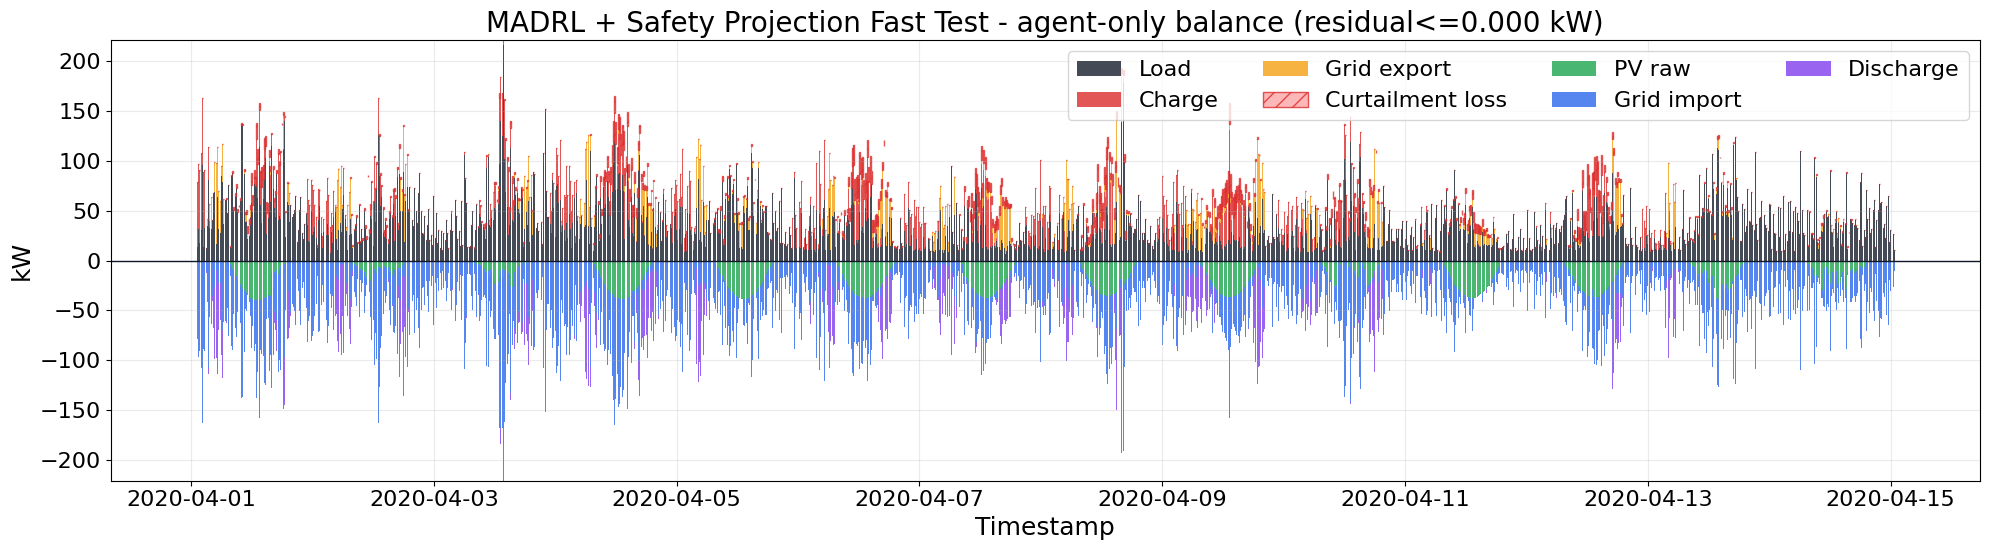

2. 电价


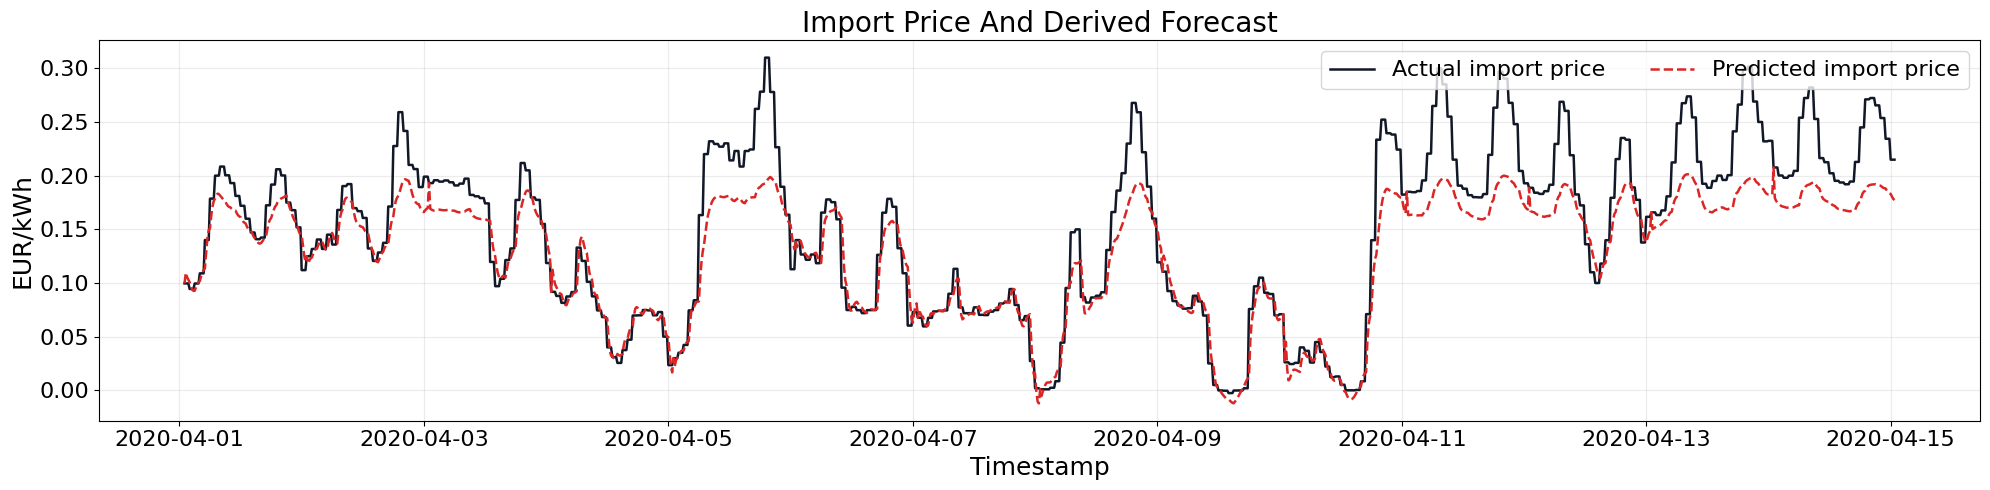

3. 储能功率与 SoC


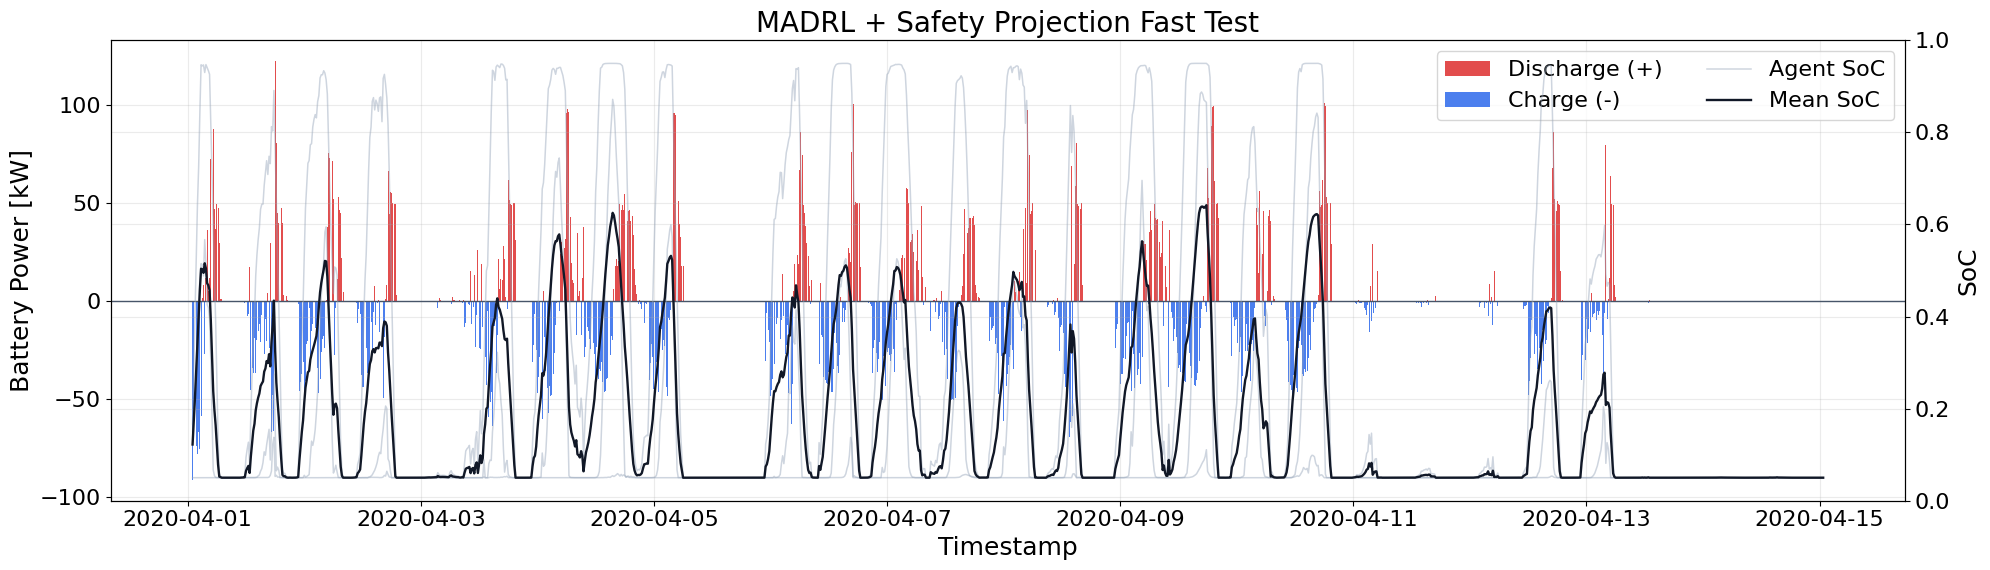

4. 电压


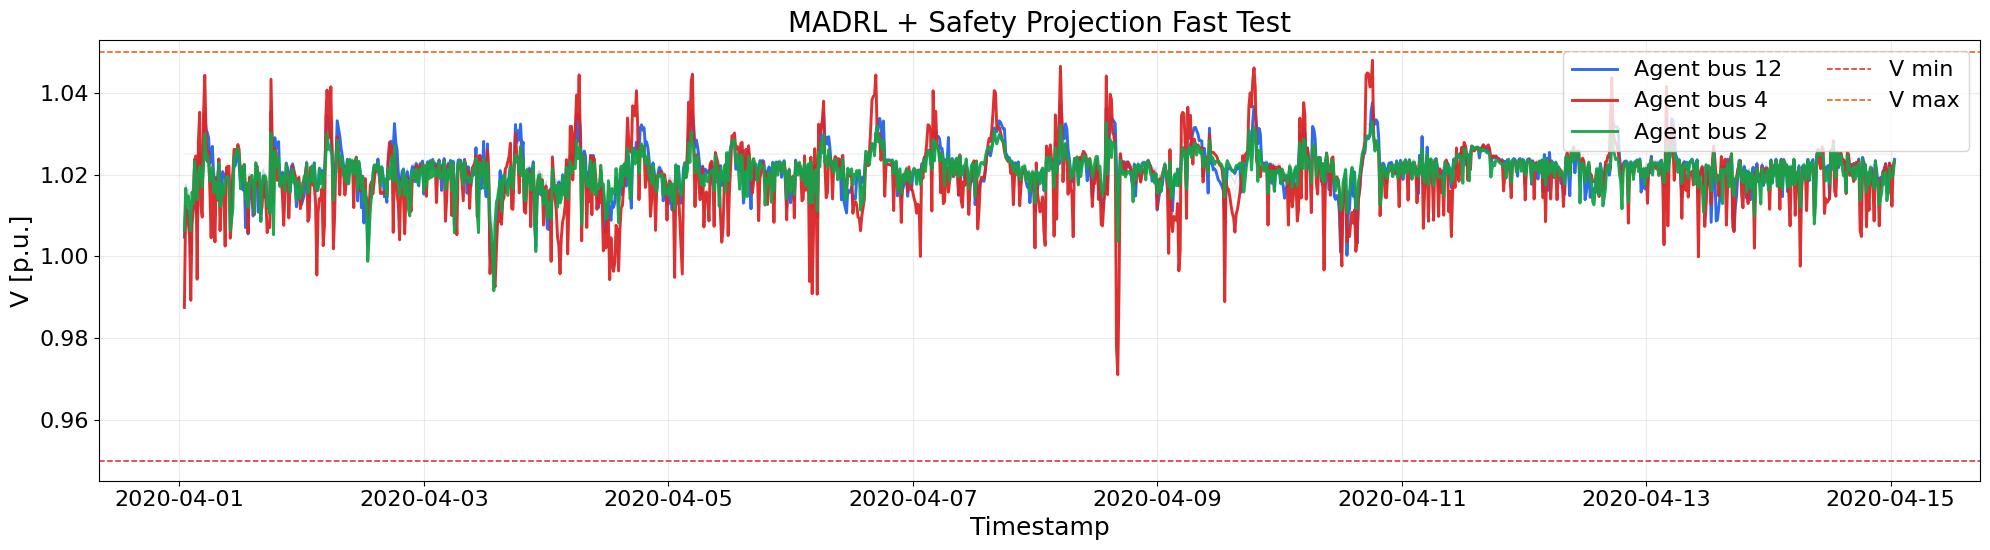

5. 净负荷


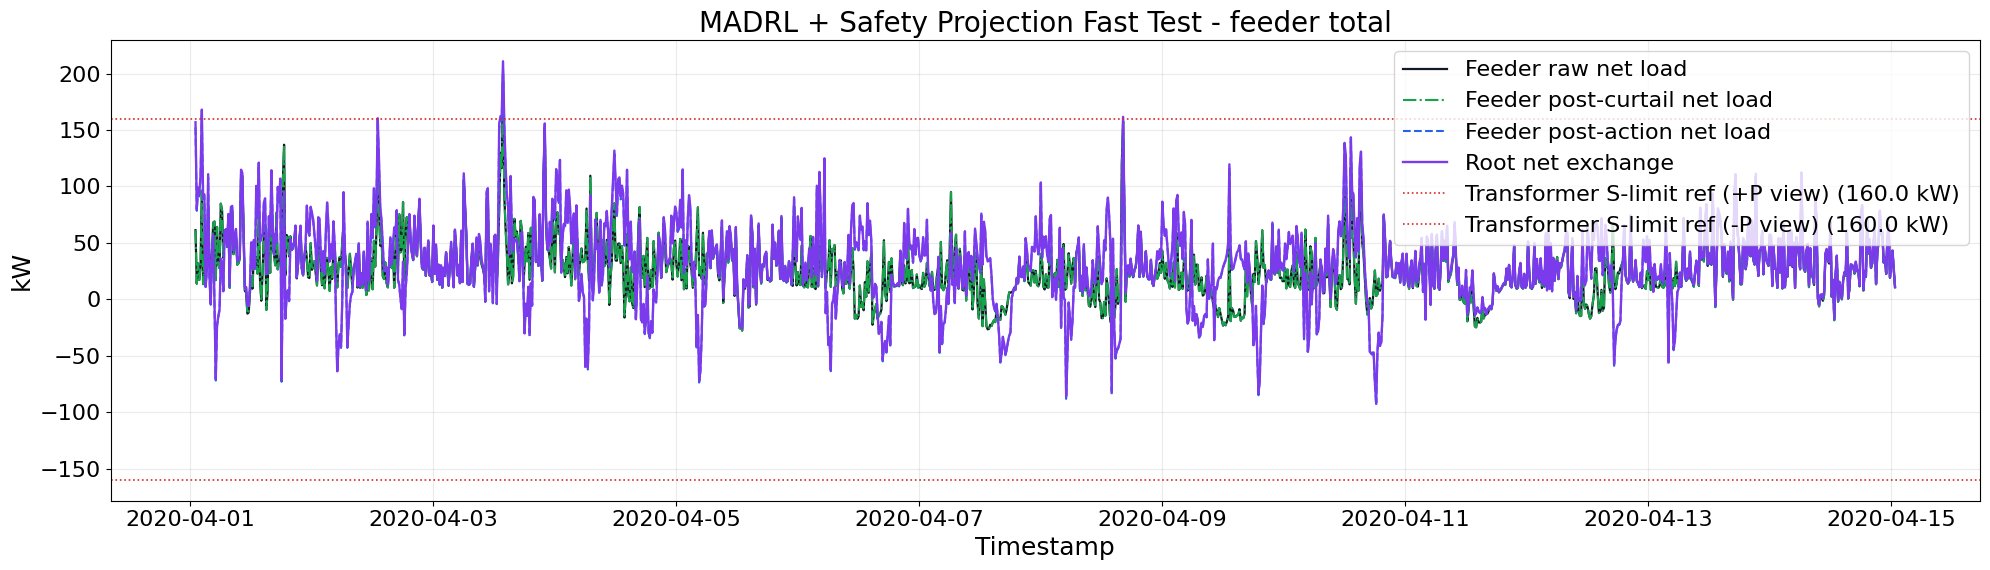

In [5]:
# 使用统一训练 helper，保证 notebook 与 mainline payload 一致。
# 训练进度条按 interaction step 前进；progress_episode_interval 控制 completed episodes 刷新。
resolved_training = resolve_madrl_notebook_training(
    cfg,
    spec=spec,
    force_retrain_madrl=bool(force_retrain_madrl),
    root=root,
    notebook_path='notebooks/madrl/train_base_fasttest.ipynb',
)
train_result = dict(resolved_training['train_result'])
result_json_path = str(resolved_training['result_json_path'])
model_root = str(resolved_training['model_root'])
train_shared_data_signature = str(train_result.get('shared_data_signature') or shared_data_signature or '')

# 用训练出的模型做 canonical rollout，并保存 compare-ready 记录到 notebooks/record。
rollout = collect_madrl_rollout(
    cfg,
    model_root=model_root,
    algorithm=str(spec['algorithm']),
    experiment_name=str(spec['experiment_name']),
    label=str(spec['display_label']),
)
metrics_df = compare_rollout_metrics(rollout)
required_profit_columns = {
    'storage_charge_cost_total_eur',
    'storage_discharge_revenue_total_eur',
    'storage_profit_total_eur',
    'storage_objective_total_eur',
}
missing_profit_columns = required_profit_columns.difference(metrics_df.columns)
if missing_profit_columns:
    raise ValueError(
        f"train_base_fasttest requires storage-profit metrics aligned with MISOCP. Missing: {sorted(missing_profit_columns)}. "
        "Rerun notebooks/madrl/train_base_fasttest.ipynb after the max-storage-profit objective migration."
    )
if rollout.meta.get('objective_mode') != 'max_storage_profit':
    raise ValueError("train_base_fasttest rollout meta must declare objective_mode='max_storage_profit'.")
record_manifest = save_rollout_record(
    rollout,
    category='madrl',
    scheme_name=str(spec['scheme_name']),
    root=root,
    config_snapshot={
        **config_snapshot,
        'model_root': model_root,
        'result_json_path': result_json_path,
        'shared_data_signature': train_shared_data_signature,
    },
    extra_meta={
        'model_root': model_root,
        'result_json_path': result_json_path,
        'shared_data_signature': train_shared_data_signature,
    },
)
training_summary_df = pd.DataFrame([{
    'episodes_completed': int(train_result.get('episodes_completed', 0)),
    'global_interaction_step': int(train_result.get('global_interaction_step', 0)),
    'target_total_steps': int(dict(train_result.get('perf_summary', {})).get('target_total_steps', 0)),
    'steps_per_sec': float(dict(train_result.get('perf_summary', {})).get('steps_per_sec', 0.0)),
    'update_calls': int(dict(train_result.get('perf_summary', {})).get('update_calls', 0)),
    'model_root': model_root,
}])
display(training_summary_df)
display(metrics_df)
display(rollout.summary)
pprint({
    'model_root': model_root,
    'result_json_path': result_json_path,
    'shared_data_signature': train_result.get('shared_data_signature'),
    'record_dir': record_manifest['record_dir'],
    'episodes_completed': int(train_result.get('episodes_completed', 0)),
})

# 绘制 MADRL 结果，保持与 MISOCP notebook 的图表口径一致。
_plot_specs = [
    ('1. 功率平衡', plot_power_balance_comparison),
    ('2. 电价', plot_price_prediction_comparison),
    ('3. 储能功率与 SoC', plot_battery_power_and_soc_comparison),
    ('4. 电压', plot_voltage_profile_comparison),
    ('5. 净负荷', plot_net_load_comparison),
]

for title, plot_fn in _plot_specs:
    print(title)
    figure = plot_fn(rollout)
    display(figure)
    plt.close(figure)

,episode,total_reward,madrl_r_inc,madrl_r_action_penalty,madrl_r_soc_regularization,madrl_r_throughput_bonus,madrl_r_safe_v,madrl_r_safe_line,madrl_r_safe_trafo,madrl_r_safe_total
486,487,-2.109659,3.779867,-5.889268,-0.000255,0.0,0.000000,0.0,0.000000,0.000000
487,488,-17.847267,-10.061857,-7.785005,-0.000410,0.0,0.000000,0.0,0.000000,0.000000
488,489,-28.315088,-22.446650,-5.841772,-0.000248,0.0,0.000000,0.0,-0.026426,-0.026426
489,490,-13.005531,-6.204082,-6.799984,-0.000224,0.0,-0.001166,0.0,-0.000079,-0.001245
490,491,-9.982179,0.031886,-9.767508,-0.000465,0.0,0.000000,0.0,-0.246096,-0.246096
491,492,-10.525992,-1.329074,-9.196517,-0.000397,0.0,0.000000,0.0,0.000000,0.000000
492,493,6.551316,11.748004,-5.188891,-0.000260,0.0,0.000000,0.0,-0.007540,-0.007540
493,494,-15.142506,-10.087162,-2.094750,-0.000148,0.0,0.000000,0.0,-2.960443,-2.960443
494,495,-27.141159,-22.274006,-4.866951,-0.000208,0.0,0.000000,0.0,0.000000,0.000000
495,496,-25.504650,-19.614317,-5.890060,-0.000241,0.0,-0.000031,0.0,0.000000,-0.000031


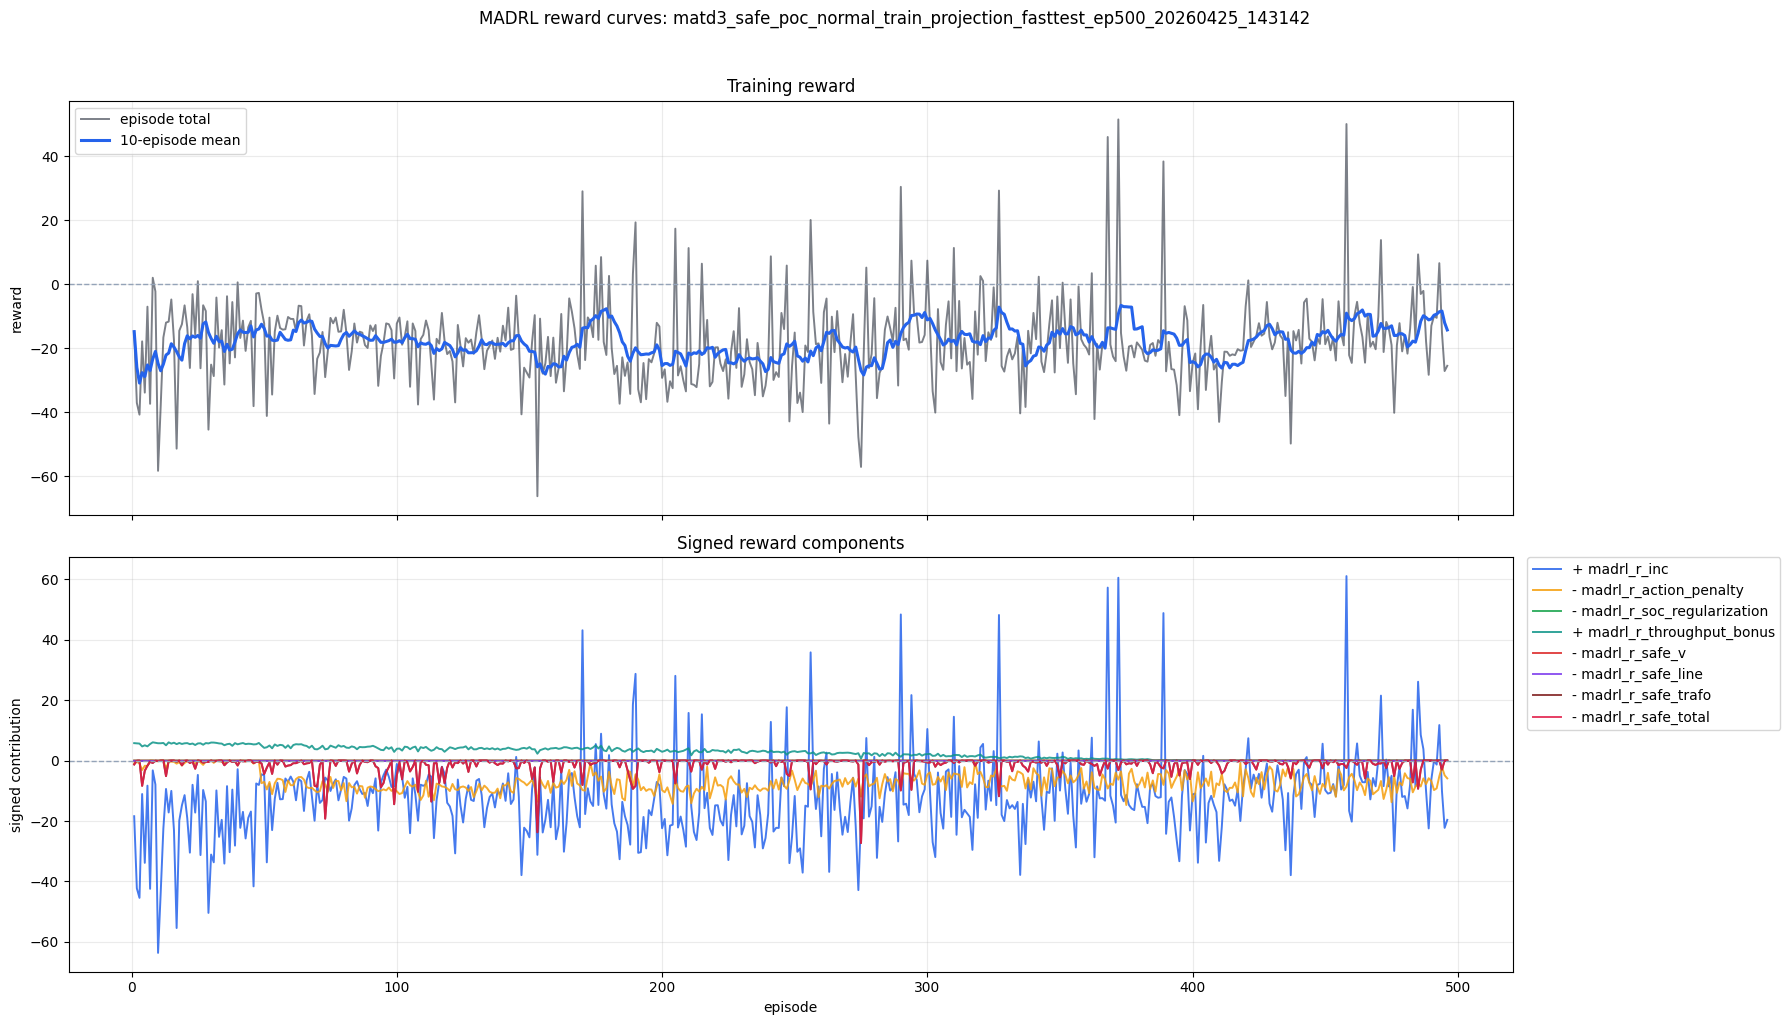

In [6]:
reward_summary_path = Path(
    train_result.get('reward_summary_path') or Path(result_json_path).with_name('train_reward_summary.json')
).resolve()
if not reward_summary_path.exists():
    raise FileNotFoundError(f"MADRL reward summary not found: {reward_summary_path}")

reward_summary = json.loads(reward_summary_path.read_text(encoding='utf-8'))
episodes = list(reward_summary.get('episodes') or [])
if not episodes:
    raise ValueError(f"MADRL reward summary '{reward_summary_path}' contains no episodes.")

reward_curve_df = pd.DataFrame({
    'episode': episodes,
    'total_reward': reward_summary.get('episode_total_reward', []),
})
if len(reward_curve_df['total_reward']) != len(episodes):
    raise ValueError("episode_total_reward length does not match episodes length.")

component_color_map = {
    'blue': '#2563eb',
    'amber': '#f59e0b',
    'green': '#16a34a',
    'teal': '#0d9488',
    'red': '#dc2626',
    'purple': '#7c3aed',
    'maroon': '#7f1d1d',
    'rose': '#e11d48',
    'slate': '#475569',
}
component_specs = []
for component_key, component_meta in dict(reward_summary.get('components') or {}).items():
    if component_key == 'madrl_r_total_internal':
        continue
    component_values = list(dict(component_meta).get('values') or [])
    if len(component_values) != len(episodes):
        raise ValueError(f"Reward component '{component_key}' length does not match episodes length.")
    reward_curve_df[component_key] = component_values
    component_specs.append((
        component_key,
        str(dict(component_meta).get('label') or component_key),
        component_color_map.get(str(dict(component_meta).get('color') or ''), '#6b7280'),
    ))

rolling_window = min(10, max(1, len(reward_curve_df)))
fig, axes = plt.subplots(2, 1, figsize=(18, 10), sharex=True)

axes[0].plot(reward_curve_df['episode'], reward_curve_df['total_reward'], color='#111827', linewidth=1.4, alpha=0.55, label='episode total')
if rolling_window > 1:
    axes[0].plot(
        reward_curve_df['episode'],
        reward_curve_df['total_reward'].rolling(rolling_window, min_periods=1).mean(),
        color='#2563eb',
        linewidth=2.2,
        label=f'{rolling_window}-episode mean',
    )
axes[0].axhline(0.0, color='#94a3b8', linewidth=1.0, linestyle='--')
axes[0].set_title('Training reward')
axes[0].set_ylabel('reward')
axes[0].grid(True, alpha=0.25)
axes[0].legend(loc='upper left')

for component_key, label, color in component_specs:
    axes[1].plot(reward_curve_df['episode'], reward_curve_df[component_key], linewidth=1.4, alpha=0.85, color=color, label=label)
axes[1].axhline(0.0, color='#94a3b8', linewidth=1.0, linestyle='--')
axes[1].set_title('Signed reward components')
axes[1].set_xlabel('episode')
axes[1].set_ylabel('signed contribution')
axes[1].grid(True, alpha=0.25)
axes[1].legend(loc='upper left', bbox_to_anchor=(1.01, 1.0), borderaxespad=0.0)

fig.suptitle(f"MADRL reward curves: {Path(model_root).name}", y=1.02)
fig.tight_layout()
display(reward_curve_df.tail(10))
display(fig)
plt.close(fig)
